**1.- Carga de datos**

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/route_cost_impact_limpio.csv")
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.head())


(3132, 23)
['month', 'conflict_phase', 'airline', 'iata_code', 'origin_city', 'destination_city', 'aircraft_type', 'original_distance_km', 'actual_distance_km', 'extra_distance_km', 'rerouted', 'flight_cancelled', 'fuel_consumption_bbl', 'brent_crude_usd', 'jet_fuel_usd_barrel', 'total_fuel_cost_usd', 'extra_fuel_cost_usd', 'base_ticket_price_usd', 'fuel_surcharge_usd', 'total_ticket_price_usd', 'estimated_passengers', 'route_revenue_usd', 'fuel_pct_of_cost']
month                         str
conflict_phase                str
airline                       str
iata_code                     str
origin_city                   str
destination_city              str
aircraft_type                 str
original_distance_km        int64
actual_distance_km        float64
extra_distance_km         float64
rerouted                      str
flight_cancelled              str
fuel_consumption_bbl      float64
brent_crude_usd           float64
jet_fuel_usd_barrel       float64
total_fuel_cost_usd       

**2.-Revisión de estructura**

Se analiza la estructura del dataset para comprender la distribución
de variables, tipos de datos y posibles valores atípicos o inconsistencias.

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3132 entries, 0 to 3131
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month                   3132 non-null   str    
 1   conflict_phase          3132 non-null   str    
 2   airline                 3132 non-null   str    
 3   iata_code               3132 non-null   str    
 4   origin_city             3132 non-null   str    
 5   destination_city        3132 non-null   str    
 6   aircraft_type           3132 non-null   str    
 7   original_distance_km    3132 non-null   int64  
 8   actual_distance_km      3132 non-null   float64
 9   extra_distance_km       3132 non-null   float64
 10  rerouted                3132 non-null   str    
 11  flight_cancelled        3132 non-null   str    
 12  fuel_consumption_bbl    3132 non-null   float64
 13  brent_crude_usd         3132 non-null   float64
 14  jet_fuel_usd_barrel     3132 non-null   float64
 15

,original_distance_km,actual_distance_km,extra_distance_km,fuel_consumption_bbl,brent_crude_usd,jet_fuel_usd_barrel,total_fuel_cost_usd,extra_fuel_cost_usd,base_ticket_price_usd,fuel_surcharge_usd,total_ticket_price_usd,estimated_passengers,route_revenue_usd,fuel_pct_of_cost
count,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000
mean,6039.611111,6078.737229,39.126117,127.033525,80.184368,93.624138,11952.704879,157.676213,498.929374,143.715801,642.645176,241.433908,152580.331651,97.259962
std,3002.592295,3033.226488,218.954889,56.761229,24.362462,28.374818,6899.205816,891.745391,300.065824,114.206751,409.861986,42.028976,101081.087401,1.344451
min,1248.000000,1248.000000,0.000000,35.000000,20.550000,23.690000,829.150000,0.000000,26.090000,1.770000,27.860000,0.000000,0.000000,89.920000
25%,4320.500000,4519.500000,0.000000,102.150000,66.500000,76.870000,6746.255000,0.000000,259.995000,65.797500,330.652500,226.000000,75378.355000,97.090000
50%,5376.500000,5418.000000,0.000000,115.000000,82.610000,94.920000,10861.190000,0.000000,448.250000,119.250000,564.875000,246.000000,136080.545000,97.600000
75%,7975.250000,8000.000000,0.000000,165.000000,91.480000,109.200000,15532.340000,0.000000,665.840000,188.247500,852.917500,266.000000,202737.262500,97.920000
max,12003.000000,14131.000000,2345.000000,282.500000,169.080000,193.200000,54579.000000,10796.970000,2046.160000,920.770000,2966.930000,284.000000,750646.560000,99.100000


**3.- Variables derivadas**

Se generan nuevas variables a partir de las columnas originales con el fin de capturar de mejor manera el impacto operacional y económico de las rutas aéreas.

Estas transformaciones facilitan el análisis posterior, especialmente para comparar fases del conflicto, desvíos, costos e ingresos.

In [6]:
# Se crea una variable 'route' combinando ciudad de origen y destino
# Esto permite agrupar y analizar datos por trayecto específico
df["route"] = df["origin_city"] + " → " + df["destination_city"]

# Se visualizan algunas filas para verificar la correcta creación
df[["origin_city", "destination_city", "route"]].head()

,origin_city,destination_city,route
0,Dubai,London,Dubai → London
1,Dubai,London,Dubai → London
2,Dubai,London,Dubai → London
3,Dubai,London,Dubai → London
4,Dubai,London,Dubai → London


In [7]:
# Se crea una variable binaria que indica si el vuelo fue afectado
# Se considera afectado si fue desviado o cancelado
df["is_disrupted"] = np.where(
    (df["rerouted"] == "Yes") | (df["flight_cancelled"] == "Yes"),
    1,
    0
)

# Se valida la lógica de la nueva variable
df[["rerouted", "flight_cancelled", "is_disrupted"]].head()

,rerouted,flight_cancelled,is_disrupted
0,No,No,0
1,No,No,0
2,No,No,0
3,No,No,0
4,No,No,0


In [8]:
# Se calcula el ingreso promedio por pasajero
# Esto permite comparar eficiencia económica entre rutas
df["revenue_per_passenger"] = (
    df["route_revenue_usd"] / df["estimated_passengers"]
)

# Se revisan los resultados
df[["route_revenue_usd", "estimated_passengers", "revenue_per_passenger"]].head()

,route_revenue_usd,estimated_passengers,revenue_per_passenger
0,101420.55,231,439.05
1,126697.62,259,489.18
2,100095.60,220,454.98
3,113218.87,263,430.49
4,121109.85,283,427.95


In [9]:
# Se calcula el costo de combustible por pasajero
# Esto ayuda a evaluar la eficiencia operativa por persona transportada
df["fuel_cost_per_passenger"] = (
    df["total_fuel_cost_usd"] / df["estimated_passengers"]
)

# Se verifican los valores
df[["total_fuel_cost_usd", "estimated_passengers", "fuel_cost_per_passenger"]].head()

,total_fuel_cost_usd,estimated_passengers,fuel_cost_per_passenger
0,8949.6,231,38.742857
1,9806.4,259,37.862548
2,9224.4,220,41.929091
3,8800.8,263,33.463118
4,8756.4,283,30.941343


In [10]:
# Se calcula una métrica simple de rentabilidad
# Diferencia entre ingresos totales de la ruta y costo total de combustible
df["revenue_minus_fuel"] = (
    df["route_revenue_usd"] - df["total_fuel_cost_usd"]
)

# Se revisan los resultados
df[["route_revenue_usd", "total_fuel_cost_usd", "revenue_minus_fuel"]].head()

,route_revenue_usd,total_fuel_cost_usd,revenue_minus_fuel
0,101420.55,8949.6,92470.95
1,126697.62,9806.4,116891.22
2,100095.60,9224.4,90871.20
3,113218.87,8800.8,104418.07
4,121109.85,8756.4,112353.45


In [11]:
# Se calcula qué proporción del costo total de combustible corresponde al costo extra
# Esto mide el impacto directo del desvío en los costos
df["extra_fuel_ratio"] = (
    df["extra_fuel_cost_usd"] / df["total_fuel_cost_usd"]
)

# Se verifican los valores calculados
df[["extra_fuel_cost_usd", "total_fuel_cost_usd", "extra_fuel_ratio"]].head()

,extra_fuel_cost_usd,total_fuel_cost_usd,extra_fuel_ratio
0,0.0,8949.6,0.0
1,0.0,9806.4,0.0
2,0.0,9224.4,0.0
3,0.0,8800.8,0.0
4,0.0,8756.4,0.0


**4.-Agregaciones**

En esta sección se realizan agrupaciones y resúmenes estadísticos sobre variables clave del dataset.

El objetivo es identificar patrones por fase del conflicto, aerolínea y trayecto, con el fin de comparar el impacto operacional y económico entre distintos grupos.


In [12]:
# Se agrupan los datos por fase del conflicto
# Se calculan promedios de variables operacionales y económicas relevantes
phase_summary = df.groupby("conflict_phase").agg({
    "extra_distance_km": "mean",
    "extra_fuel_cost_usd": "mean",
    "total_fuel_cost_usd": "mean",
    "fuel_surcharge_usd": "mean",
    "route_revenue_usd": "mean",
    "estimated_passengers": "mean"
}).reset_index()

# Se muestra la tabla resumen para revisar los resultados
phase_summary

,conflict_phase,extra_distance_km,extra_fuel_cost_usd,total_fuel_cost_usd,fuel_surcharge_usd,route_revenue_usd,estimated_passengers
0,COVID-19 Collapse,0.000000,0.000000,7426.494815,62.362333,93126.796648,247.748148
1,Gaza-Israel Conflict,0.000000,0.000000,12452.723810,149.211726,165711.980159,245.309524
2,Pre-Iran Escalation,0.000000,0.000000,13956.180741,187.532315,192302.618657,246.953704
3,Pre-Pandemic Baseline,0.000000,0.000000,9443.405714,85.403214,118202.838492,244.851190
4,Recovery & Surge,0.000000,0.000000,11148.928395,120.488364,146441.747469,247.456790
5,Stabilisation,0.000000,0.000000,12784.487901,157.120093,172613.289228,247.638889
6,US-Iran War Conflict,850.993056,3429.457639,24007.091111,387.423542,204969.058750,158.305556
7,Ukraine War Shock,0.000000,0.000000,14303.880889,198.467250,190377.645361,237.375000


In [13]:
# Se agrupan los datos por aerolínea y fase del conflicto
# Se calculan promedios para comparar cómo se ve afectada cada aerolínea en cada fase
airline_phase_summary = df.groupby(["airline", "conflict_phase"]).agg({
    "extra_distance_km": "mean",
    "extra_fuel_cost_usd": "mean",
    "route_revenue_usd": "mean",
    "is_disrupted": "mean"
}).reset_index()

# Se muestran las primeras filas de la tabla generada
airline_phase_summary.head()

,airline,conflict_phase,extra_distance_km,extra_fuel_cost_usd,route_revenue_usd,is_disrupted
0,Air Arabia,COVID-19 Collapse,0.0,0.0,33114.358000,0.0
1,Air Arabia,Gaza-Israel Conflict,0.0,0.0,60182.735000,0.0
2,Air Arabia,Pre-Iran Escalation,0.0,0.0,68449.435000,0.0
3,Air Arabia,Pre-Pandemic Baseline,0.0,0.0,41528.695000,0.0
4,Air Arabia,Recovery & Surge,0.0,0.0,53028.493333,0.0


In [14]:
# Se calcula el porcentaje de aumento de distancia respecto a la ruta original
# Esto permite comparar el impacto relativo de los desvíos entre rutas
df["distance_increase_pct"] = (
    df["extra_distance_km"] / df["original_distance_km"]
) * 100

# Se revisan algunas filas para comprobar que la variable fue creada correctamente
df[["original_distance_km", "extra_distance_km", "distance_increase_pct"]].head()

,original_distance_km,extra_distance_km,distance_increase_pct
0,5500,0.0,0.0
1,5500,0.0,0.0
2,5500,0.0,0.0
3,5500,0.0,0.0
4,5500,0.0,0.0


In [15]:
# Se agrupan los datos por ruta y fase del conflicto
# Esto permite identificar trayectos con mayor impacto en distancia, costo e ingresos
route_phase_summary = df.groupby(["route", "conflict_phase"]).agg({
    "extra_distance_km": "mean",
    "extra_fuel_cost_usd": "mean",
    "route_revenue_usd": "mean",
    "distance_increase_pct": "mean"
}).reset_index()

# Se muestran las primeras filas para validar el resultado
route_phase_summary.head()

,route,conflict_phase,extra_distance_km,extra_fuel_cost_usd,route_revenue_usd,distance_increase_pct
0,Abu Dhabi → Chicago,COVID-19 Collapse,0.0,0.0,166569.887333,0.0
1,Abu Dhabi → Chicago,Gaza-Israel Conflict,0.0,0.0,304996.644286,0.0
2,Abu Dhabi → Chicago,Pre-Iran Escalation,0.0,0.0,353414.562500,0.0
3,Abu Dhabi → Chicago,Pre-Pandemic Baseline,0.0,0.0,212397.452857,0.0
4,Abu Dhabi → Chicago,Recovery & Surge,0.0,0.0,273343.274444,0.0


In [16]:
# Se agrupan los datos por ruta
# Se calcula el costo extra promedio de combustible por trayecto
# Luego se ordenan de mayor a menor para identificar las rutas más afectadas
top_routes_extra_fuel = df.groupby("route").agg({
    "extra_fuel_cost_usd": "mean"
}).reset_index().sort_values(by="extra_fuel_cost_usd", ascending=False)

# Se muestran las 10 rutas con mayor costo extra promedio
top_routes_extra_fuel.head(10)

,route,extra_fuel_cost_usd
20,Dubai → New York,321.864943
30,New York → Dubai,305.033908
9,Doha → New York,287.596897
5,Bangkok → London,286.801839
22,Dubai → Sydney,281.532414
10,Doha → Tokyo,261.901379
33,Seoul → Dubai,244.200805
28,Mumbai → London,241.031724
0,Abu Dhabi → Chicago,237.473448
7,Doha → Kuala Lumpur,223.340000


In [17]:
# Se calcula el porcentaje de aumento de distancia respecto a la ruta original
# Esto permite comparar el impacto relativo de los desvíos entre rutas
df["distance_increase_pct"] = (
    df["extra_distance_km"] / df["original_distance_km"]
) * 100

# Se revisan algunas filas para comprobar que la variable fue creada correctamente
df[["original_distance_km", "extra_distance_km", "distance_increase_pct"]].head()

,original_distance_km,extra_distance_km,distance_increase_pct
0,5500,0.0,0.0
1,5500,0.0,0.0
2,5500,0.0,0.0
3,5500,0.0,0.0
4,5500,0.0,0.0


In [18]:
# Se agrupan los datos según si el vuelo fue afectado o no
# Esto permite comparar el comportamiento económico y operacional
# entre vuelos interrumpidos y vuelos sin interrupción
disruption_summary = df.groupby("is_disrupted").agg({
    "extra_distance_km": "mean",
    "extra_fuel_cost_usd": "mean",
    "total_fuel_cost_usd": "mean",
    "route_revenue_usd": "mean",
    "estimated_passengers": "mean"
}).reset_index()

# Se muestran los resultados del resumen
disruption_summary

,is_disrupted,extra_distance_km,extra_fuel_cost_usd,total_fuel_cost_usd,route_revenue_usd,estimated_passengers
0,0,0.000000,0.00000,11345.140953,150611.808682,246.745065
1,1,856.944056,3453.43986,24652.065524,193726.591469,130.419580


In [19]:
# Se exportan las tablas resumen generadas en esta sección
# Se utiliza una ruta relativa correcta considerando que el notebook se ejecuta desde la carpeta 'notebooks'
phase_summary.to_csv("../outputs/tables/phase_summary.csv", index=False)
airline_phase_summary.to_csv("../outputs/tables/airline_phase_summary.csv", index=False)
route_phase_summary.to_csv("../outputs/tables/route_phase_summary.csv", index=False)
top_routes_extra_fuel.to_csv("../outputs/tables/top_routes_extra_fuel.csv", index=False)
disruption_summary.to_csv("../outputs/tables/disruption_summary.csv", index=False)

**5.-Joins y comparaciones contra baseline**

En esta sección se construye una referencia base utilizando el período pre-pandemia, con el objetivo de comparar el comportamiento de las rutas en otras fases del conflicto.

Para ello, se generan tablas resumen base y luego se aplican joins que permiten calcular diferencias en variables económicas y operacionales respecto de esa referencia.

In [20]:
# Se filtran únicamente los registros correspondientes al período base pre-pandemia
# Luego se agrupan por ruta para obtener una referencia promedio por trayecto
baseline_route = df[df["conflict_phase"] == "Pre-Pandemic Baseline"].groupby("route").agg({
    "total_fuel_cost_usd": "mean",
    "route_revenue_usd": "mean",
    "fuel_surcharge_usd": "mean",
    "extra_distance_km": "mean"
}).reset_index()

# Se renombran las columnas para distinguir claramente los valores baseline
baseline_route = baseline_route.rename(columns={
    "total_fuel_cost_usd": "baseline_fuel_cost",
    "route_revenue_usd": "baseline_revenue",
    "fuel_surcharge_usd": "baseline_surcharge",
    "extra_distance_km": "baseline_extra_distance"
})

# Se muestran las primeras filas para verificar la tabla baseline
baseline_route.head()

,route,baseline_fuel_cost,baseline_revenue,baseline_surcharge,baseline_extra_distance
0,Abu Dhabi → Chicago,16309.825714,212397.452857,155.898571,0.0
1,Abu Dhabi → London,8828.254286,104019.322857,76.614286,0.0
2,Addis Ababa → Dubai,5835.625714,63770.111429,47.795000,0.0
3,Amsterdam → Dubai,8379.360000,107938.508571,74.533571,0.0
4,Bahrain → London,8379.360000,102322.522143,72.541429,0.0


In [21]:
# Se realiza un join entre el dataset principal y la tabla baseline por ruta
# Esto permite asociar a cada registro sus valores de referencia del período pre-pandemia
df_baseline_compare = df.merge(
    baseline_route,
    on="route",
    how="left"
)

# Se muestran algunas filas para verificar que el merge se realizó correctamente
df_baseline_compare[[
    "route",
    "conflict_phase",
    "total_fuel_cost_usd",
    "baseline_fuel_cost",
    "route_revenue_usd",
    "baseline_revenue"
]].head()

,route,conflict_phase,total_fuel_cost_usd,baseline_fuel_cost,route_revenue_usd,baseline_revenue
0,Dubai → London,Pre-Pandemic Baseline,8949.6,8977.885714,101420.55,111203.279286
1,Dubai → London,Pre-Pandemic Baseline,9806.4,8977.885714,126697.62,111203.279286
2,Dubai → London,Pre-Pandemic Baseline,9224.4,8977.885714,100095.60,111203.279286
3,Dubai → London,Pre-Pandemic Baseline,8800.8,8977.885714,113218.87,111203.279286
4,Dubai → London,Pre-Pandemic Baseline,8756.4,8977.885714,121109.85,111203.279286


In [22]:
# Se calculan diferencias entre los valores actuales y los valores baseline
# Esto permite medir cuánto cambió cada ruta respecto al período de referencia
df_baseline_compare["fuel_cost_delta"] = (
    df_baseline_compare["total_fuel_cost_usd"] - df_baseline_compare["baseline_fuel_cost"]
)

df_baseline_compare["revenue_delta"] = (
    df_baseline_compare["route_revenue_usd"] - df_baseline_compare["baseline_revenue"]
)

df_baseline_compare["surcharge_delta"] = (
    df_baseline_compare["fuel_surcharge_usd"] - df_baseline_compare["baseline_surcharge"]
)

df_baseline_compare["extra_distance_delta"] = (
    df_baseline_compare["extra_distance_km"] - df_baseline_compare["baseline_extra_distance"]
)

# Se muestran algunas filas para comprobar que las diferencias fueron calculadas correctamente
df_baseline_compare[[
    "route",
    "conflict_phase",
    "fuel_cost_delta",
    "revenue_delta",
    "surcharge_delta",
    "extra_distance_delta"
]].head()

,route,conflict_phase,fuel_cost_delta,revenue_delta,surcharge_delta,extra_distance_delta
0,Dubai → London,Pre-Pandemic Baseline,-28.285714,-9782.729286,-0.652143,0.0
1,Dubai → London,Pre-Pandemic Baseline,828.514286,15494.340714,14.827857,0.0
2,Dubai → London,Pre-Pandemic Baseline,246.514286,-11107.679286,4.157857,0.0
3,Dubai → London,Pre-Pandemic Baseline,-177.085714,2015.590714,-3.192143,0.0
4,Dubai → London,Pre-Pandemic Baseline,-221.485714,9906.570714,-3.942143,0.0


In [23]:
# Se agrupan los datos por fase del conflicto
# Se calculan promedios de las diferencias respecto al baseline
# Esto permite observar el impacto promedio de cada fase
delta_summary = df_baseline_compare.groupby("conflict_phase").agg({
    "fuel_cost_delta": "mean",
    "revenue_delta": "mean",
    "surcharge_delta": "mean",
    "extra_distance_delta": "mean"
}).reset_index()

# Se muestran los resultados
delta_summary

,conflict_phase,fuel_cost_delta,revenue_delta,surcharge_delta,extra_distance_delta
0,COVID-19 Collapse,-2.016911e+03,-2.507604e+04,-2.304088e+01,0.000000
1,Gaza-Israel Conflict,3.009318e+03,4.750914e+04,6.380851e+01,0.000000
2,Pre-Iran Escalation,4.512775e+03,7.409978e+04,1.021291e+02,0.000000
3,Pre-Pandemic Baseline,5.503887e-14,7.940033e-13,7.049035e-16,0.000000
4,Recovery & Surge,1.705523e+03,2.823891e+04,3.508515e+01,0.000000
5,Stabilisation,3.341082e+03,5.441045e+04,7.171688e+01,0.000000
6,US-Iran War Conflict,1.456369e+04,8.676622e+04,3.020203e+02,850.993056
7,Ukraine War Shock,4.860475e+03,7.217481e+04,1.130640e+02,0.000000


In [24]:
# Se agrupan los datos por ruta y fase del conflicto
# Esto permite identificar qué trayectos fueron más afectados en cada fase
route_delta_summary = df_baseline_compare.groupby(["route", "conflict_phase"]).agg({
    "fuel_cost_delta": "mean",
    "revenue_delta": "mean",
    "extra_distance_delta": "mean"
}).reset_index()

# Se muestran algunas filas
route_delta_summary.head()

,route,conflict_phase,fuel_cost_delta,revenue_delta,extra_distance_delta
0,Abu Dhabi → Chicago,COVID-19 Collapse,-3.483432e+03,-4.582757e+04,0.0
1,Abu Dhabi → Chicago,Gaza-Israel Conflict,5.197431e+03,9.259919e+04,0.0
2,Abu Dhabi → Chicago,Pre-Iran Escalation,7.794071e+03,1.410171e+05,0.0
3,Abu Dhabi → Chicago,Pre-Pandemic Baseline,-2.598556e-13,1.870961e-11,0.0
4,Abu Dhabi → Chicago,Recovery & Surge,2.945630e+03,6.094582e+04,0.0


In [25]:
# Se agrupan los datos por ruta y fase del conflicto
# Esto permite identificar qué trayectos fueron más afectados en cada fase
route_delta_summary = df_baseline_compare.groupby(["route", "conflict_phase"]).agg({
    "fuel_cost_delta": "mean",
    "revenue_delta": "mean",
    "extra_distance_delta": "mean"
}).reset_index()

# Se muestran algunas filas
route_delta_summary.head()

,route,conflict_phase,fuel_cost_delta,revenue_delta,extra_distance_delta
0,Abu Dhabi → Chicago,COVID-19 Collapse,-3.483432e+03,-4.582757e+04,0.0
1,Abu Dhabi → Chicago,Gaza-Israel Conflict,5.197431e+03,9.259919e+04,0.0
2,Abu Dhabi → Chicago,Pre-Iran Escalation,7.794071e+03,1.410171e+05,0.0
3,Abu Dhabi → Chicago,Pre-Pandemic Baseline,-2.598556e-13,1.870961e-11,0.0
4,Abu Dhabi → Chicago,Recovery & Surge,2.945630e+03,6.094582e+04,0.0


In [26]:
# Se identifican las rutas con mayor aumento promedio en costo de combustible respecto al baseline
# Esto permite detectar los trayectos más afectados económicamente
top_route_impact = route_delta_summary.groupby("route").agg({
    "fuel_cost_delta": "mean"
}).reset_index().sort_values(by="fuel_cost_delta", ascending=False)

# Se muestran las 10 rutas con mayor impacto
top_route_impact.head(10)

,route,fuel_cost_delta
22,Dubai → Sydney,7092.854286
20,Dubai → New York,6640.388720
30,New York → Dubai,6521.153042
9,Doha → New York,6426.607798
0,Abu Dhabi → Chicago,6408.388476
35,Singapore → London,6127.687187
5,Bangkok → London,5808.162804
24,Hong Kong → London,5738.591920
12,Dubai → Cape Town,4924.363259
10,Doha → Tokyo,4879.109211


In [27]:
# Se exportan los resultados del análisis baseline
delta_summary.to_csv("../outputs/tables/delta_summary.csv", index=False)
route_delta_summary.to_csv("../outputs/tables/route_delta_summary.csv", index=False)
top_route_impact.to_csv("../outputs/tables/top_route_impact.csv", index=False)

**Interpretación de comparaciones contra baseline**

El análisis comparativo respecto al período pre-pandemia permite observar cambios significativos en variables operacionales y económicas.

En particular, se identifican:

- disminuciones en ingresos y costos durante el colapso por COVID-19
- aumentos sostenidos en costos de combustible y recargos en fases de conflicto
- incremento en ingresos asociado a ajustes tarifarios
- casos específicos de aumento en distancia recorrida, indicando desvíos de rutas

Estos resultados permiten comprender el impacto diferencial de cada fase del conflicto sobre la operación aérea.

**6.-Tablas pivote y reshape**

En esta sección se reorganizan los datos utilizando operaciones de pivot y reshape, con el objetivo de facilitar la comparación entre fases del conflicto y mejorar la interpretación de resultados.

Estas transformaciones permiten estructurar la información en formatos más adecuados para visualización y análisis.

In [28]:
# Se crea una tabla pivote para visualizar el costo de combustible promedio por fase del conflicto
# Esto permite comparar fácilmente cómo varía el costo entre distintas fases
pivot_fuel_cost = df_baseline_compare.pivot_table(
    values="fuel_cost_delta",
    index="route",
    columns="conflict_phase",
    aggfunc="mean"
)

# Se muestran algunas filas de la tabla pivote
pivot_fuel_cost.head()

conflict_phase,COVID-19 Collapse,Gaza-Israel Conflict,Pre-Iran Escalation,Pre-Pandemic Baseline,Recovery & Surge,Stabilisation,US-Iran War Conflict,Ukraine War Shock
route,,,,,,,,
Abu Dhabi → Chicago,-3483.432381,5197.431429,7794.070952,-2.598556e-13,2945.629841,5770.425397,24648.394286,8394.588286
Abu Dhabi → London,-1885.527619,2813.288571,4218.809048,2.598556e-13,1594.423492,3123.441270,13518.838214,4543.859714
Addis Ababa → Dubai,-1246.365714,1859.631429,2788.704286,3.248195e-13,1053.940952,2064.647619,9505.389286,3003.568286
Amsterdam → Dubai,-1789.653333,2670.240000,4004.293333,1.104386e-12,1513.351111,2964.622222,13068.720000,4312.816000
Bahrain → London,-1789.653333,2670.240000,4004.293333,1.104386e-12,1513.351111,2964.622222,12398.707500,4312.816000


In [29]:
# Se crea una tabla pivote para visualizar los cambios en ingresos por ruta y fase
# Esto permite analizar cómo varía el revenue en cada contexto
pivot_revenue = df_baseline_compare.pivot_table(
    values="revenue_delta",
    index="route",
    columns="conflict_phase",
    aggfunc="mean"
)

# Se muestran algunas filas
pivot_revenue.head()

conflict_phase,COVID-19 Collapse,Gaza-Israel Conflict,Pre-Iran Escalation,Pre-Pandemic Baseline,Recovery & Surge,Stabilisation,US-Iran War Conflict,Ukraine War Shock
route,,,,,,,,
Abu Dhabi → Chicago,-45827.565524,92599.191429,141017.109643,1.870961e-11,60945.821587,108608.357143,30078.512143,151977.318143
Abu Dhabi → London,-22260.330857,45981.969286,62471.229643,-5.197113e-12,25637.482698,53680.070476,79898.884643,54479.998143
Addis Ababa → Dubai,-13097.068762,26353.042857,43571.319405,-6.236535e-12,24704.184127,28535.994127,76063.866071,50019.349571
Amsterdam → Dubai,-24853.083905,36608.830714,62385.423929,-1.039423e-11,20420.642540,43460.539206,105431.698929,72415.366429
Bahrain → London,-24706.198143,34875.955714,67898.002024,-9.354803e-12,17700.751190,52299.205635,173150.747857,72342.313857


In [30]:
# Se reinicia el índice para convertir 'route' en una columna normal
# Esto facilita exportar y manipular la tabla posteriormente
pivot_fuel_cost = pivot_fuel_cost.reset_index()
pivot_revenue = pivot_revenue.reset_index()

# Se muestran resultados para verificar
pivot_fuel_cost.head()

conflict_phase,route,COVID-19 Collapse,Gaza-Israel Conflict,Pre-Iran Escalation,Pre-Pandemic Baseline,Recovery & Surge,Stabilisation,US-Iran War Conflict,Ukraine War Shock
0,Abu Dhabi → Chicago,-3483.432381,5197.431429,7794.070952,-2.598556e-13,2945.629841,5770.425397,24648.394286,8394.588286
1,Abu Dhabi → London,-1885.527619,2813.288571,4218.809048,2.598556e-13,1594.423492,3123.441270,13518.838214,4543.859714
2,Addis Ababa → Dubai,-1246.365714,1859.631429,2788.704286,3.248195e-13,1053.940952,2064.647619,9505.389286,3003.568286
3,Amsterdam → Dubai,-1789.653333,2670.240000,4004.293333,1.104386e-12,1513.351111,2964.622222,13068.720000,4312.816000
4,Bahrain → London,-1789.653333,2670.240000,4004.293333,1.104386e-12,1513.351111,2964.622222,12398.707500,4312.816000


In [31]:
# Se calcula el impacto total por ruta sumando los cambios en costo de combustible en todas las fases
# Esto permite identificar qué rutas fueron más afectadas globalmente
pivot_fuel_cost["total_impact"] = pivot_fuel_cost.drop(columns=["route"]).sum(axis=1)

# Se ordenan las rutas de mayor a menor impacto
pivot_fuel_cost_sorted = pivot_fuel_cost.sort_values(by="total_impact", ascending=False)

# Se muestran las rutas más impactadas
pivot_fuel_cost_sorted.head(10)

conflict_phase,route,COVID-19 Collapse,Gaza-Israel Conflict,Pre-Iran Escalation,Pre-Pandemic Baseline,Recovery & Surge,Stabilisation,US-Iran War Conflict,Ukraine War Shock,total_impact
22,Dubai → Sydney,-3834.971429,5721.942857,8580.628571,2.598556e-13,3242.895238,6352.761905,27437.828571,9241.748571,56742.834286
20,Dubai → New York,-3515.390476,5245.114286,7865.576190,-3.897834e-13,2972.653968,5823.365079,26260.187857,8471.602857,53123.109762
30,New York → Dubai,-3467.453333,5173.590000,7758.318333,2.598556e-13,2932.117778,5743.955556,25672.615000,8356.081000,52169.224333
9,Doha → New York,-3435.495238,5125.907143,7686.813095,-1.299278e-13,2905.093651,5691.015873,25160.461429,8279.066429,51412.862381
0,Abu Dhabi → Chicago,-3483.432381,5197.431429,7794.070952,-2.598556e-13,2945.629841,5770.425397,24648.394286,8394.588286,51267.107810
35,Singapore → London,-3355.600000,5006.700000,7508.050000,-9.094947e-13,2837.533333,5558.666667,23379.617500,8086.530000,49021.497500
5,Bangkok → London,-3067.977143,4577.554286,6864.502857,-2.598556e-13,2594.316190,5082.209524,23021.297857,7393.398857,46465.302429
24,Hong Kong → London,-3115.914286,4649.078571,6971.760714,9.094947e-13,2634.852381,5161.619048,22098.418214,7508.920714,45908.735357
12,Dubai → Cape Town,-2636.542857,3933.835714,5899.182143,1.169350e-12,2229.490476,4367.523810,19247.714643,6353.702143,39394.906071
10,Doha → Tokyo,-2556.647619,3814.628571,5720.419048,-1.429206e-12,2161.930159,4235.174603,19496.203214,6161.165714,39032.873690


In [32]:
# Se exportan las tablas pivote generadas
# Estas tablas serán útiles para visualizaciones y análisis posteriores
pivot_fuel_cost_sorted.to_csv("../outputs/tables/pivot_fuel_cost.csv", index=False)
pivot_revenue.to_csv("../outputs/tables/pivot_revenue.csv", index=False)

**Interpretación de tablas pivote**

Las tablas pivote permiten visualizar de manera clara cómo varían los costos de combustible y los ingresos entre distintas fases del conflicto.

Se observa que ciertas rutas concentran un mayor impacto acumulado, lo que sugiere una mayor exposición a cambios operacionales y económicos.

Este tipo de transformación facilita la comparación directa entre fases y mejora la capacidad de análisis para la toma de decisiones.

**7.-Visualizaciones**

En esta sección se presentan gráficos que permiten interpretar de forma visual los cambios en costos, ingresos y comportamiento operacional a lo largo de las distintas fases del conflicto.

Las visualizaciones facilitan la identificación de patrones, tendencias y anomalías en los datos.

In [33]:
# Se importan librerías necesarias para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Se configura estilo de gráficos
sns.set(style="whitegrid")

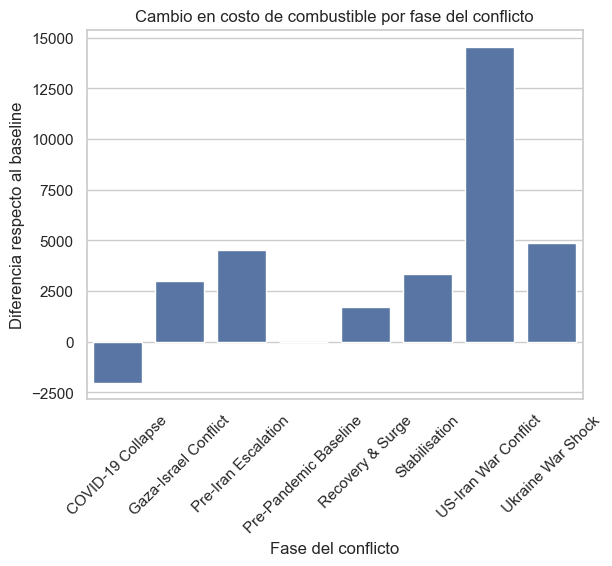

In [35]:
# Se crea un gráfico de barras para visualizar el cambio en costo de combustible por fase
plt.figure()

sns.barplot(
    data=delta_summary,
    x="conflict_phase",
    y="fuel_cost_delta"
)

# Se rota el eje X para mejor visualización
plt.xticks(rotation=45)

# Se agregan títulos y etiquetas
plt.title("Cambio en costo de combustible por fase del conflicto")
plt.xlabel("Fase del conflicto")
plt.ylabel("Diferencia respecto al baseline")

# Se guarda el gráfico en la carpeta correspondiente
plt.savefig("../outputs/figures/fuel_cost_by_phase.png")

# Se muestra el gráfico
plt.show()

Se observa una disminución en los costos durante el colapso por COVID-19, seguida de un aumento progresivo en fases posteriores, alcanzando su máximo durante el conflicto US-Iran, lo que evidencia un fuerte impacto en los costos operacionales.

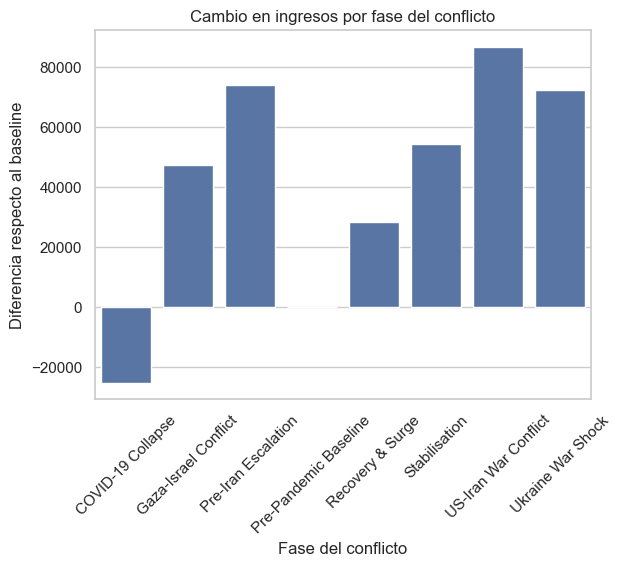

In [36]:
# Se crea un gráfico de barras para visualizar el cambio en ingresos por fase
plt.figure()

sns.barplot(
    data=delta_summary,
    x="conflict_phase",
    y="revenue_delta"
)

# Se rota el eje X para mejor visualización
plt.xticks(rotation=45)

# Se agregan títulos y etiquetas
plt.title("Cambio en ingresos por fase del conflicto")
plt.xlabel("Fase del conflicto")
plt.ylabel("Diferencia respecto al baseline")

# Se guarda el gráfico
plt.savefig("../outputs/figures/revenue_by_phase.png")

# Se muestra el gráfico
plt.show()

Durante la fase de COVID-19 se observa una fuerte caída en los ingresos, mientras que en fases posteriores, especialmente en conflictos geopolíticos como US-Iran, los ingresos aumentan significativamente, lo que sugiere ajustes en precios y demanda.

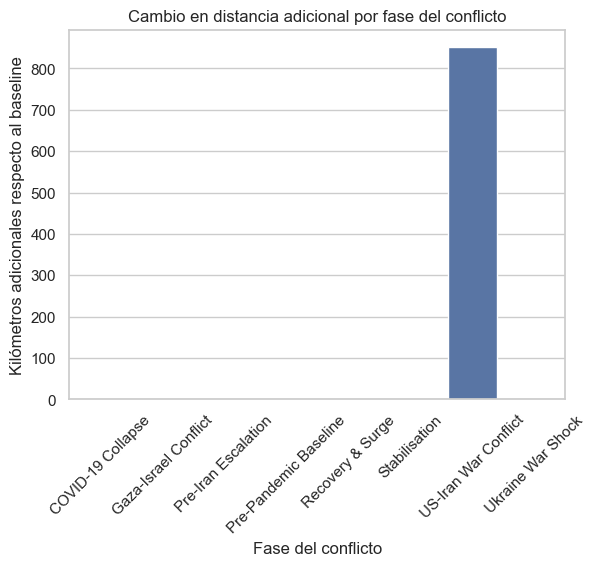

In [37]:
# Se crea un gráfico para visualizar el aumento de distancia por fase
plt.figure()

sns.barplot(
    data=delta_summary,
    x="conflict_phase",
    y="extra_distance_delta"
)

# Rotación para legibilidad
plt.xticks(rotation=45)

# Títulos
plt.title("Cambio en distancia adicional por fase del conflicto")
plt.xlabel("Fase del conflicto")
plt.ylabel("Kilómetros adicionales respecto al baseline")

# Guardar
plt.savefig("../outputs/figures/extra_distance_by_phase.png")

# Mostrar
plt.show()

In [ ]:
#pruebaxd
print("pruebacris")

A diferencia de otras fases, el conflicto US-Iran generó un aumento significativo en la distancia de las rutas, lo que indica desvíos operacionales reales debido a restricciones geopolíticas, mientras que en otras fases el impacto fue principalmente económico y no físico.

**8.-Hallazgos**

A partir del análisis realizado sobre el dataset de rutas aéreas, se identifican los siguientes hallazgos clave:

1. Impacto diferenciado por fase del conflicto  
Se observa que no todas las fases del conflicto tienen el mismo impacto sobre las operaciones. Mientras algunas afectan principalmente los costos, otras generan cambios estructurales en las rutas.

2. Caída significativa durante el COVID-19  
Durante la fase "COVID-19 Collapse" se evidencia una fuerte disminución tanto en ingresos como en costos de combustible, lo que refleja una contracción en la demanda y reducción de operaciones aéreas.

3. Incremento progresivo en costos e ingresos  
En fases posteriores, especialmente "Recovery & Surge", "Stabilisation" y conflictos geopolíticos, se observa un aumento sostenido en costos de combustible e ingresos, lo que sugiere una recuperación de la demanda junto con un encarecimiento operativo.

4. Impacto extremo en conflicto US-Iran  
La fase "US-Iran War Conflict" presenta el mayor incremento en costos de combustible y, además, es la única que muestra un aumento significativo en la distancia recorrida, indicando desvíos operacionales relevantes.

5. Diferencia entre impacto económico y operativo  
Mientras la mayoría de las fases afectan variables económicas (costos, ingresos, recargos), solo ciertas situaciones generan cambios físicos en las rutas (como el aumento de distancia), lo que evidencia distintos tipos de impacto según el contexto.

6. Rol del recargo de combustible  
El fuel surcharge aumenta en fases de conflicto, lo que sugiere que las aerolíneas trasladan parte del incremento de costos a los pasajeros.

**9.-Resumen para presentación**



El análisis del dataset permitió identificar cómo distintas fases del conflicto impactan las operaciones de rutas aéreas.

Se observó que durante el COVID-19 hubo una fuerte caída en ingresos y costos, reflejando una disminución en la demanda. En fases posteriores, especialmente en contextos de conflicto geopolítico, los costos de combustible y los ingresos aumentan significativamente.

El conflicto US-Iran destaca como el evento con mayor impacto, no solo en costos, sino también en la distancia recorrida, evidenciando desvíos operacionales reales.

En general, los resultados muestran que los conflictos afectan tanto el componente económico (costos e ingresos) como el operacional (rutas), aunque no todas las fases generan el mismo tipo de impacto.